# Part 2: K-Means Clustering — Finding Natural Segments
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Early afternoon — Customer Segmentation

Yesterday Sarah looked at the data in 2D. Today she finds the actual groups. She wants 3–6 customer segments — enough to be meaningful, few enough to actually act on with NorthStar's marketing team.

K-Means is the standard tool. Three big questions to answer:
1. **What K?** (How many clusters?)
2. **How well do they actually cluster?** (Silhouette score)
3. **What does each cluster MEAN?** (Profiling — naming each one)

**By the end of this notebook you will be able to:**
- Fit K-Means in one line
- Choose K with the elbow method + silhouette score
- Profile each cluster (what makes it distinctive)
- Name your clusters for a non-technical stakeholder

In [1]:
# Setup
import numpy as np                      # numpy = fast maths on lists/arrays of numbers
import pandas as pd                     # pandas = tool for working with tables of data
import matplotlib.pyplot as plt         # matplotlib = draws charts
import seaborn as sns                   # seaborn = prettier statistical charts, built on matplotlib
import warnings                         # lets us hide noisy library warning messages

from sklearn.preprocessing import StandardScaler, OneHotEncoder # scale numbers to comparable units / turn categories into 0-1 columns
from sklearn.compose import ColumnTransformer # lets us prep numeric and category columns differently
from sklearn.pipeline import Pipeline   # chains prep steps so they always run in the right order
from sklearn.impute import SimpleImputer # fills in missing values
from sklearn.decomposition import PCA   # PCA = compresses many features into a few summary axes
from sklearn.cluster import KMeans      # K-Means = groups similar customers together
from sklearn.metrics import silhouette_score # measures how well-separated the clusters are

warnings.filterwarnings("ignore")       # hide warning messages that clutter the output
sns.set_style("whitegrid")              # chart style: white background with grid lines
plt.rcParams["figure.figsize"] = (11, 4.5) # default chart size (width, height in inches)

print("✅ Libraries loaded — KMeans ready")

✅ Libraries loaded — KMeans ready


## Step 1 — Setup (same preprocessing as NB 02)

In [2]:
df = pd.read_csv("data/northstar_customers.csv") # load the same 10,000 NorthStar customers as L03/L04
features = df.drop(columns=["customer_id", "churned"])

numeric_features = ["age", "tenure_months", "num_purchases_quarter",
                    "avg_monthly_spend_gbp", "returns_per_purchase",
                    "last_login_days_ago", "avg_review_polarity",
                    "support_tickets_quarter"]
categorical_features = ["region", "subscription_tier"]

# Build one preprocessing recipe — numbers and categories need different treatment
preprocessor = ColumnTransformer([
    # Numeric columns: fill gaps with the median, then scale so no feature dominates by sheer size
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features),
    # Category columns: fill gaps with the most common value, then one 0/1 column per category
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_features),
])

X_processed = preprocessor.fit_transform(features) # learn the prep recipe from the data and apply it in one step
print(f"Processed shape: {X_processed.shape}")

Processed shape: (10000, 17)


## Step 2 — How to pick K?

K-Means doesn't tell you K. You have to decide. Two standard heuristics:

### 1. Elbow method — Inertia (within-cluster sum of squares)

**Inertia** is the total squared distance from each customer to their assigned cluster centre.

> For every customer: compute the distance to their cluster's centre → square it → sum all of these up.

Lower inertia = tighter clusters. But there's a catch: adding more clusters *always* reduces inertia — at the extreme, K = N gives inertia of zero (each customer is their own cluster of one). So we don't minimise inertia; we look for the **elbow** — the K where adding one more cluster gives diminishing returns on tightness.

### 2. Silhouette score — how well does each customer fit their cluster?

For each customer, the silhouette score compares two things:
- **a** = mean distance to all other customers *in the same cluster* (cohesion — how tight is this cluster?)
- **b** = mean distance to all customers *in the nearest other cluster* (separation — how far from the next-best option?)

$$\text{silhouette} = \frac{b - a}{\max(a, b)}$$

- Score near **+1** → customer is much closer to their own cluster than any other (well-placed)
- Score near **0** → customer sits on the boundary between two clusters (ambiguous)
- Score near **−1** → customer would fit better in a neighbouring cluster (misassigned)

The overall silhouette score is the **mean across all customers**. Higher is better — and unlike inertia, it doesn't always improve with more K. It peaks at the K that best balances cohesion and separation.

We'll compute both for K = 2, 3, ..., 10.

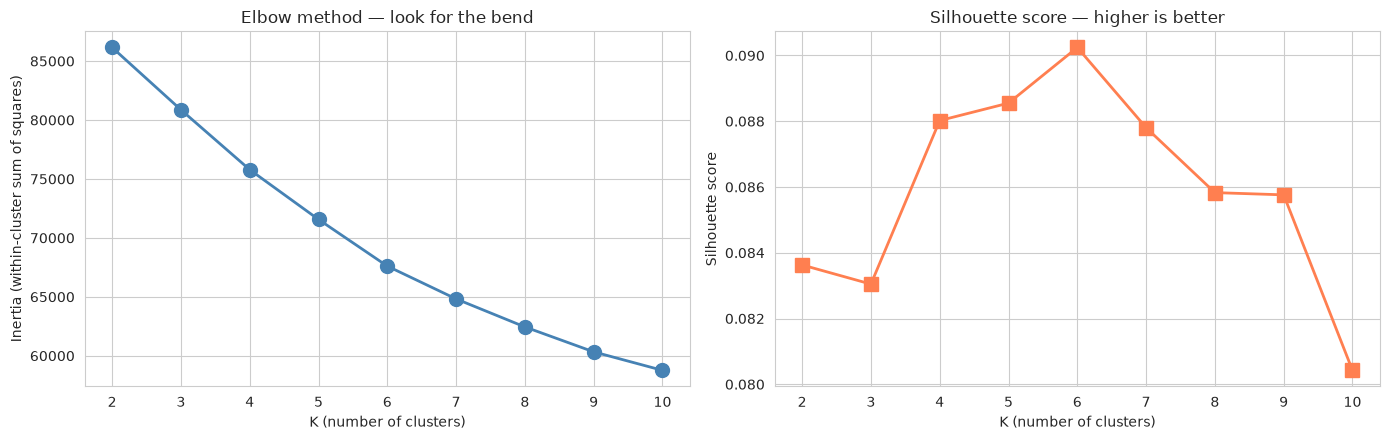

K     Inertia    Silhouette
  2        86155     0.0836
  3        80868     0.0830
  4        75787     0.0880
  5        71564     0.0886
  6        67604     0.0902
  7        64821     0.0878
  8        62444     0.0858
  9        60330     0.0858
  10        58760     0.0804


In [3]:
K_range = range(2, 11)
inertias = []
silhouettes = []

# Try each K: fit K-Means and record two quality measures
for k in K_range:
    # n_init=10 = try 10 random starting points, keep the best result
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_processed)
    # inertia = tightness: total squared distance from customers to their cluster centre (lower = tighter)
    inertias.append(km.inertia_)
    # silhouette = separation: how much closer customers are to their own cluster than the next one
    silhouettes.append(silhouette_score(X_processed, labels))

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(K_range, inertias, "o-", linewidth=2, color="steelblue", markersize=10)
axes[0].set_xlabel("K (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].set_title("Elbow method — look for the bend")

axes[1].plot(K_range, silhouettes, "s-", linewidth=2, color="coral", markersize=10)
axes[1].set_xlabel("K (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score — higher is better")

plt.tight_layout()
plt.show()

print("K     Inertia    Silhouette")
for k, inertia, sil in zip(K_range, inertias, silhouettes):
    print(f"  {k}   {inertia:10.0f}     {sil:.4f}")

## ⏸️ Pause and Predict

Look at the elbow plot and silhouette plot. Before reading on, decide:
- What K would you pick?
- What would you tell Marcus if he asked WHY?

*Your prediction:*

> *Hints to consider:*
> - The elbow plot's "bend" is rarely sharp on real data. Often it's a smooth curve — look for where the slope starts to flatten.
> - Silhouette score peaks at SOME K — check the printed table to find which K scores highest. That's the statistical vote.
> - **Business judgement matters.** The silhouette-optimal K is not always the most *actionable* K. A very high K (e.g. 8–10) segments customers finely but multiplies operational complexity — six different email tracks, six sets of offers. A very low K (e.g. 2) is easy to brief but too coarse to be useful. Sweet spot for most business contexts: **3–5 segments**.

## Step 3 — Pick K = 4

We'll commit to **K = 4**.

From the printed table, silhouette peaks at **K = 6** (score 0.0902). So why not K = 6?

| Consideration | K = 6 | K = 4 |
|---|---|---|
| **Silhouette score** | 0.0902 ✓ (best) | 0.0880 (close) |
| **Statistical signal** | Marginally tighter clusters | Nearly identical quality |
| **Operational cost** | 6 email tracks, 6 offer sets, 6 slide rows | 4 — manageable for one marketing team |
| **Presentation clarity** | Hard to name 6 distinct segments crisply | 4 clear names fit on a slide |

The score difference between K=4 and K=6 is 0.002 — essentially noise at this dataset size. The business cost of 6 segments over 4 is real. **We pick K = 4.**

> **The general rule:** optimise for the smallest K that still gives meaningfully different segments, and that a non-technical stakeholder can act on. Here, K = 4 meets that bar.

In [4]:
K = 4                                        # our chosen number of clusters (from the elbow + silhouette evidence)
km = KMeans(n_clusters=K, random_state=42, n_init=10) # build the model: 4 groups, 10 random restarts, fixed seed for reproducibility
labels = km.fit_predict(X_processed)         # find the 4 groups AND return each customer's group number (0-3)

# Add cluster labels to the original dataframe (with raw features)
df_clustered = features.copy()               # copy so we don't modify the original table
df_clustered["cluster"] = labels             # new column: which group each customer landed in

# Cluster sizes
print(f"K = {K}")
print()
print("Cluster sizes:")
print(df_clustered["cluster"].value_counts().sort_index().to_string()) # count customers per group, in group order

K = 4

Cluster sizes:
cluster
0    3463
1    1138
2    3540
3    1859


### 🔗 How does K = 4 relate to the PC1/PC2 plot coming up?

These are **two separate steps doing two different jobs** — it's worth being clear before you read the plot:

- **K = 4 is the *grouping* decision.** K-Means just assigned every customer a label (0–3) using **all 17 dimensions**. That "4" came from the elbow + silhouette analysis plus business judgement — PCA had nothing to do with it.
- **PC1/PC2 is just the *picture*.** In the next step PCA squashes those 17 dimensions down to 2 so we can draw the result on a flat screen. PCA does **not** re-cluster anything and does not know K = 4 exists.

The upcoming scatter plot stacks these two layers on one chart:

| Layer | Comes from | What it controls |
|---|---|---|
| **Where each dot sits** (its PC1, PC2 coordinates) | PCA | position on the map |
| **What colour each dot is** (0–3) | K-Means (Step 3) | which segment it belongs to |

So: **PCA places the dots, K-Means colours them.** You'll see roughly 4 coloured regions *because we chose 4 groups and 4 colours* — not because PC1/PC2 naturally split the data into 4. If we'd picked K = 6, the exact same axes would just show 6 colours.

One caveat to keep in mind: PC1 + PC2 capture only ~22% of the total spread, so groups K-Means separated cleanly in 17-D can look squished together on this 2-D map. That overlap is mostly an artefact of flattening — which is why Extension 4 adds a 3-D view to recover more of the separation.

## Step 4 — Visualise clusters in PCA space

Project to 2D with PCA (from NB 02) and colour by cluster. This is the picture Sarah will put on the end-of-day slides.

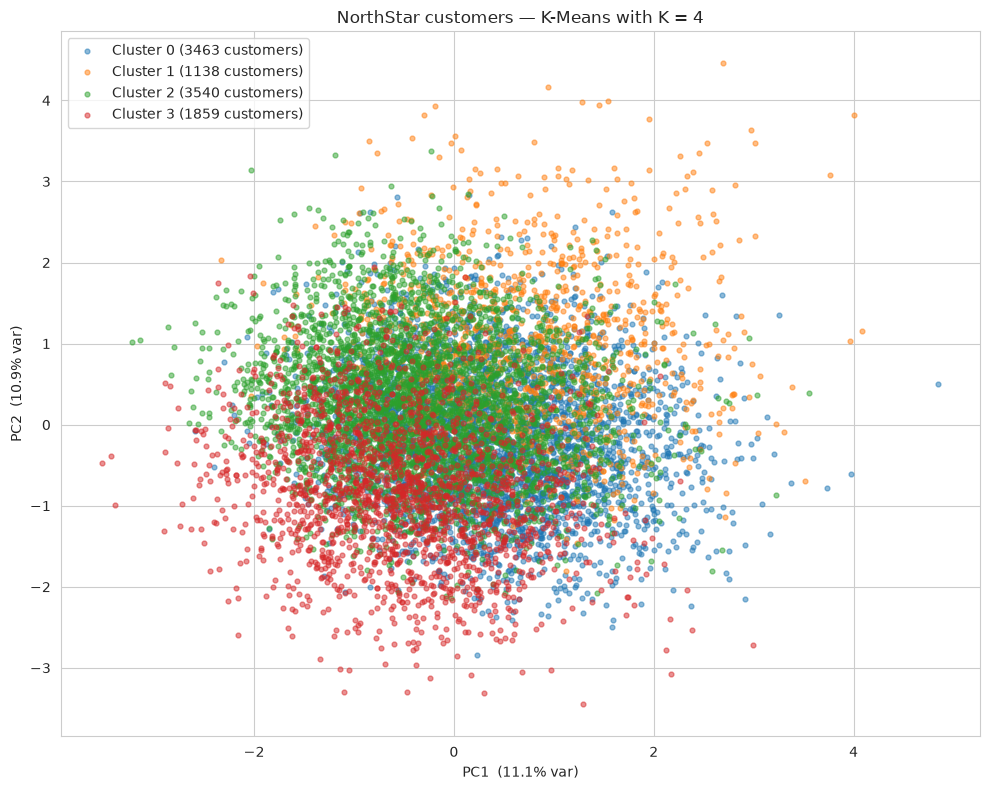

In [5]:
pca_2d = PCA(n_components=2)                 # squash 17 columns down to 2 so we can draw the clusters
X_2d = pca_2d.fit_transform(X_processed)     # every customer becomes 2 map coordinates

fig, ax = plt.subplots(figsize=(10, 8))      # blank canvas
colors = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728"] # one fixed colour per cluster
for c in range(K):                           # draw one cluster at a time
    mask = labels == c                       # True for customers in this cluster
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], # plot only those customers' map coordinates
                alpha=0.5, s=12, color=colors[c], # semi-transparent dots so overlaps stay visible
                label=f"Cluster {c} ({mask.sum()} customers)") # legend entry includes the head-count
ax.set_xlabel(f"PC1  ({pca_2d.explained_variance_ratio_[0]:.1%} var)") # axis label shows how much info PC1 carries
ax.set_ylabel(f"PC2  ({pca_2d.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"NorthStar customers — K-Means with K = {K}")
ax.legend(loc="best")                        # let matplotlib pick the least-crowded corner for the legend
plt.tight_layout()
plt.show()

### 💡 What you should notice

- The clusters are **visible in PCA space**, even though the 2D coloured cloud wasn't obviously separable in NB 02.
- K-Means is using ALL 17 dimensions to find the groups — the 2D plot is just a projection of that result.
- Some overlap is normal. K-Means assigns every customer to exactly ONE cluster (hard assignment) — there are no "in-between" customers.

## Step 5 — Cluster profiles: what makes each cluster distinctive?

For each cluster, compute the mean of every feature. Compare to the global mean to spot what each cluster is about.

In [6]:
# Profile each cluster on the ORIGINAL (unscaled) numeric features — real units are easier to interpret
numeric_cols = ["age", "tenure_months", "num_purchases_quarter",
                "avg_monthly_spend_gbp", "returns_per_purchase",
                "last_login_days_ago", "avg_review_polarity",
                "support_tickets_quarter"]

profile = df_clustered.groupby("cluster")[numeric_cols].mean().round(2) # average of each feature, per cluster
global_mean = features[numeric_cols].mean().round(2)   # average across ALL customers, for comparison
profile.loc["GLOBAL_MEAN"] = global_mean     # add the overall average as an extra row at the bottom

print("Cluster profiles vs global mean:")
print(profile.to_string())                   # print the whole table so we can compare each cluster to the average

Cluster profiles vs global mean:
               age  tenure_months  num_purchases_quarter  avg_monthly_spend_gbp  returns_per_purchase  last_login_days_ago  avg_review_polarity  support_tickets_quarter
cluster                                                                                                                                                                 
0            48.97          54.90                   6.05                  71.07                  0.09                21.33                 0.16                     1.25
1            49.69          36.48                   6.10                  70.55                  0.13                91.90                 0.12                     1.17
2            48.48          16.52                   6.00                  68.82                  0.10                20.92                 0.13                     1.15
3            48.41          36.25                   5.98                  68.62                  0.31                22.01

## Step 6 — Heatmap of standardised differences

A heatmap makes the "what's different" pattern visible at a glance. Standardise each cluster's mean by subtracting the global mean and dividing by the global standard deviation.

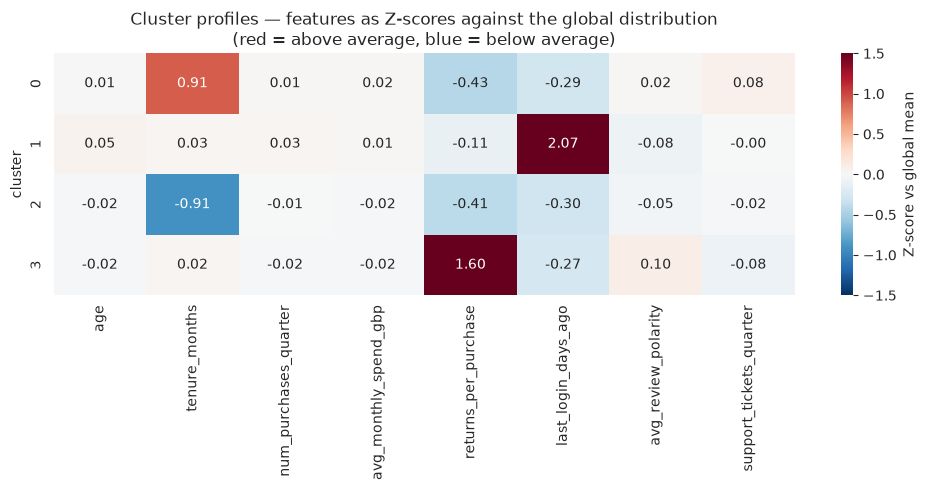

In [7]:
# Z-score each cluster's mean against the global distribution
# (z-score = "how many standard deviations above/below the overall average" — puts all features on one scale)
global_std  = features[numeric_cols].std()   # how spread-out each feature is overall
cluster_means = df_clustered.groupby("cluster")[numeric_cols].mean() # average of each feature, per cluster
z_scores = (cluster_means - global_mean) / global_std # distance from the overall average, in "spread" units

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(z_scores, annot=True, fmt=".2f", cmap="RdBu_r", center=0, # one coloured square per cluster × feature, number printed inside
            vmin=-1.5, vmax=1.5, cbar_kws={"label": "Z-score vs global mean"}, ax=ax) # fix the colour range so shades are comparable
ax.set_title(f"Cluster profiles — features as Z-scores against the global distribution\n(red = above average, blue = below average)")
plt.tight_layout()
plt.show()

### 💡 What this tells us — naming the clusters

Each row of the heatmap has one or two dominant colours. That's the signal. Everything else is noise.

| Cluster | Size | Dominant signals | Name |
|---|---|---|---|
| **0** | 3,463 (35%) | `tenure_months` +0.91 ↑, `returns` −0.43 ↓, `last_login` −0.29 ↓ | **"Loyal Veterans"** |
| **1** | 1,138 (11%) | `last_login_days_ago` +2.07 ↑↑ (everything else average) | **"Dormant / At-Risk"** |
| **2** | 3,540 (35%) | `tenure_months` −0.91 ↓, `returns` −0.41 ↓, `last_login` −0.30 ↓ | **"New Actives"** |
| **3** | 1,859 (19%) | `returns_per_purchase` +1.60 ↑↑ (everything else average) | **"Serial Returners"** |

**Reading each cluster:**

- **Cluster 0 — "Loyal Veterans"** (35% of base): Long-tenured, few returns, recently logged in. The healthiest segment. Prime candidates for loyalty rewards or a premium upsell campaign.

- **Cluster 1 — "Dormant / At-Risk"** (11% of base): Average on almost every feature — but they haven't logged in for a very long time (last login +2.07 SD above the mean). They look fine on paper; they're silently churning. Top priority for a re-engagement campaign.

- **Cluster 2 — "New Actives"** (35% of base): New customers (short tenure) who are nonetheless recently active and returning little. They're engaged and finding what they want. Onboarding, early loyalty incentives, and cross-sell are the right plays.

- **Cluster 3 — "Serial Returners"** (19% of base): Return rate is the single defining feature — dramatically above average (+1.60 SD). Everything else is unremarkable. This could be size/fit issues, expectation mismatches, or opportunistic buy-return behaviour. Worth a product team conversation before running any promotions on this group.

**Key insight:** The clearest signals in this dataset are *tenure*, *login recency*, and *return rate* — not spend or age. That's what the data is telling Sarah and Marcus to act on.

## ✅ Section Summary

| What we did | Output |
|---|---|
| **Computed elbow + silhouette** for K = 2-10 | Two metrics for choosing K |
| **Picked K = 4** | Business judgement — actionable number of segments |
| **Fit K-Means** | 4 cluster labels, one per customer |
| **Plotted in PCA space** | Visible groupings even when raw 2D wasn't obvious |
| **Profiled each cluster** | Per-cluster feature means + heatmap of Z-score differences |
| **Named the segments** | The output Marcus actually wants — meaningful labels, not numbers |

**Key insight for our scenario:**
> K-Means alone gives Sarah numbers (cluster 0, 1, 2, 3). The VALUE comes from profiling — translating "cluster 0" into "Loyal Veterans, 35% of base, candidates for loyalty rewards or a premium upsell campaign."

---
**Up next → Part 3:** Isolation Forest for anomaly detection. Find unusual customers worth investigating.
Open `04_isolation_forest.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Reproducibility: K-Means and random_state

K-Means starts from random initial centroids. With `n_init=10` (set explicitly here), it tries 10 different starting points and keeps the best. But two runs with different `random_state` can still land on different solutions — on this data, noticeably different cluster ASSIGNMENTS and sizes.

ALWAYS set `random_state` for reproducible work — and treat borderline customers as soft assignments, because a different seed can move them.

In [ ]:
# Compare K-Means with two different random_states — does the "randomness" change the answer?
km_42  = KMeans(n_clusters=4, random_state=42, n_init=10)  # run 1: seed 42
km_123 = KMeans(n_clusters=4, random_state=123, n_init=10) # run 2: same settings, different seed

labels_42  = km_42.fit_predict(X_processed)  # cluster assignments from run 1
labels_123 = km_123.fit_predict(X_processed) # cluster assignments from run 2

# Cluster sizes — a first rough check that the two runs found similar groups
sizes_42  = pd.Series(labels_42).value_counts().sort_index().values
sizes_123 = pd.Series(labels_123).value_counts().sort_index().values

print(f"Cluster sizes with random_state=42:   {sizes_42}")
print(f"Cluster sizes with random_state=123:  {sizes_123}")

# Pairwise agreement — what fraction of customers got the SAME cluster?
# (Note: cluster IDs might be permuted between the two runs. Best to use ARI.)
from sklearn.metrics import adjusted_rand_score # compares two clusterings: 1 = identical, 0 = random
ari = adjusted_rand_score(labels_42, labels_123) # agreement score that ignores the arbitrary cluster numbering
print()
print(f"Adjusted Rand Index between the two runs: {ari:.3f}")
print("→ ARI ≈ 1 means same clustering. ARI ≈ 0 means random agreement.")
print("→ An ARI well below 1 means the seeds disagree on many customers — these segments are NOT fully stable. Fix random_state for reproducibility, and treat borderline customers as soft assignments.")

## Extension 2 — When K-Means struggles: non-globular clusters

K-Means assumes clusters are SPHERICAL (roughly equal in all directions). When the natural clusters are elongated, stringy, or irregularly shaped, K-Means fails — it carves up the natural shapes into pieces.

For non-globular structure, use **DBSCAN** (density-based) — covered in `optional_extensions.ipynb`.

For now, here's a synthetic demo to make the limitation visible.

In [ ]:
from sklearn.datasets import make_moons # generates a toy "two moons" dataset for the demo

# Two interlocking moons — clearly two groups, but not spherical
X_moons, _ = make_moons(n_samples=400, noise=0.05, random_state=42) # 400 points, a little jitter, fixed seed

km_demo = KMeans(n_clusters=2, random_state=42, n_init=10) # ask K-Means for 2 groups
labels_demo = km_demo.fit_predict(X_moons)   # let it try to find the two moons

fig, axes = plt.subplots(1, 2, figsize=(13, 5)) # before / after, side by side

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], s=20, color="gray", alpha=0.6) # left: the raw points, uncoloured
axes[0].set_title("Two natural 'moons' — humans see clear groups")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_demo, cmap="coolwarm", s=20, alpha=0.7) # right: coloured by K-Means's answer
axes[1].set_title("K-Means with K=2 → carves the moons in half (the wrong way)")

plt.tight_layout()
plt.show()
print("→ K-Means fails on non-globular shapes. Use DBSCAN if you suspect this.")

## Extension 3 — Mini-batch K-Means for large datasets

For very large datasets (>100k rows), regular K-Means is slow. `MiniBatchKMeans` uses random subsets each iteration — much faster, almost as accurate.

In [ ]:
from sklearn.cluster import MiniBatchKMeans # faster K-Means that works on random subsets
import time                             # lets us time how long code takes to run

# Time regular vs mini-batch
start = time.time()                          # note the clock before we start
km_full = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_processed) # regular K-Means on ALL rows at once
t_full = time.time() - start                 # how many seconds it took

start = time.time()                          # reset the stopwatch
km_mini = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=512, n_init=10).fit(X_processed) # mini-batch: 512 rows at a time
t_mini = time.time() - start

# Compare cluster qualities — did the shortcut cost us anything?
sil_full = silhouette_score(X_processed, km_full.labels_) # separation quality of the full run
sil_mini = silhouette_score(X_processed, km_mini.labels_) # separation quality of the fast run

print(f"Full KMeans:    time = {t_full*1000:.0f}ms, silhouette = {sil_full:.4f}")
print(f"MiniBatch:      time = {t_mini*1000:.0f}ms, silhouette = {sil_mini:.4f}")
print()
print("MiniBatchKMeans is the right choice when full KMeans takes >10s.")
print("For our 10k-row dataset, the difference is small. For 1M+ rows it's enormous.")

## Extension 4 — Seeing the clusters more clearly

In **Step 4** all four clusters were drawn on top of each other in one 2D PCA scatter, and they overlap heavily. That overlap is partly real and partly an artefact of the picture:

- **It's partly real.** The silhouette score here is only ~0.09 — these are *soft* segments defined by a few features (tenure, login recency, return rate), not sharply separated blobs. No plot can make genuinely-overlapping data look cleanly split, and pretending otherwise would be dishonest.
- **It's partly the plot.** PC1 + PC2 capture only a slice of the 17-dimensional variance, and 10,000 semi-transparent dots piled in one axes hide every centre. We can fix *this* part with better plotting choices.

Three techniques that make the structure far easier to read — **none of them change the clustering, only how we look at it**:

1. **Small multiples (facets)** — one panel per cluster. Each panel greys out everyone else and highlights one cluster plus its **centroid (★)**. Overplotting disappears, and you can see where each group actually sits.
2. **A 3D PCA view** — add PC3 as a third axis. Groups that sit on top of each other in 2D often pull apart along the extra dimension.
3. **Centroid markers** — even on the combined plot, drawing the four centres as large stars makes "where is each cluster's centre of gravity" obvious, which was the original complaint.

> 💡 **Takeaway for slides:** for a non-technical audience, the *faceted* view and the *named heatmap* from Step 6 communicate the segments far better than a single overlapping scatter. The scatter shows "the model found structure"; the facets + heatmap show "here is what each group is."

In [ ]:
# Extension 4 — clearer views of the SAME K=4 clustering (no re-fitting)
# Reuses `km`, `labels`, `X_processed`, `pca_2d`, `X_2d`, `colors`, `K` from Steps 3-4.

cluster_names = ["Loyal Veterans", "Dormant / At-Risk", "New Actives", "Serial Returners"] # business names from the profiling step

# Project the cluster centroids into the same 2D PCA space as the customers
centroids_2d = pca_2d.transform(km.cluster_centers_) # the 4 cluster "centres of gravity", as map coordinates

# ----------------------------------------------------------------------
# VIEW 1 — Small multiples: one panel per cluster (kills overplotting)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, K, figsize=(5 * K, 5), sharex=True, sharey=True) # 4 panels in a row, same axes so they're comparable
for c in range(K):                           # build one panel per cluster
    ax = axes[c]
    # Everyone else, in light grey for context
    other = labels != c                      # True for customers NOT in this cluster
    ax.scatter(X_2d[other, 0], X_2d[other, 1], s=6, color="lightgrey", alpha=0.4) # faint background dots
    # This cluster, highlighted
    mask = labels == c                       # True for customers IN this cluster
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=10, color=colors[c], alpha=0.6) # coloured dots on top
    # Its centroid as a big star
    ax.scatter(centroids_2d[c, 0], centroids_2d[c, 1],
               marker="*", s=600, color=colors[c], edgecolor="black", linewidth=1.5, zorder=5) # zorder=5 = draw on top of everything
    ax.set_title(f"Cluster {c} — {cluster_names[c]}\n({mask.sum()} customers)") # panel title includes the head-count
    ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")                    # only the leftmost panel needs a y label
fig.suptitle("View 1 — Small multiples: each segment highlighted, ★ = centroid", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# VIEW 2 — 3D PCA: add PC3 so groups that overlap in 2D can pull apart
# ----------------------------------------------------------------------
pca_3d = PCA(n_components=3)                 # same idea as before, but keep 3 directions instead of 2
X_3d = pca_3d.fit_transform(X_processed)     # every customer becomes 3 coordinates
centroids_3d = pca_3d.transform(km.cluster_centers_) # cluster centres in the same 3D space

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")   # a 3D set of axes instead of the usual flat one
for c in range(K):                           # draw each cluster's dots + its centroid star
    mask = labels == c
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],           # x, y, z for this cluster's customers
               s=8, color=colors[c], alpha=0.35, label=f"Cluster {c} — {cluster_names[c]}")
    ax.scatter(centroids_3d[c, 0], centroids_3d[c, 1], centroids_3d[c, 2], # the centroid, as a big star
               marker="*", s=500, color=colors[c], edgecolor="black", linewidth=1.5)
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})")     # each axis label shows its share of the information
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})")
ax.set_title("View 2 — 3D PCA (PC1 + PC2 + PC3), ★ = centroid")
ax.legend(loc="upper left", fontsize=8)
ax.view_init(elev=18, azim=45)   # rotate this angle to explore the structure
plt.tight_layout()
plt.show()

cum_var = pca_3d.explained_variance_ratio_.sum() # total information kept by the 3 components together
print(f"PC1-PC3 together capture {cum_var:.1%} of total variance "
      f"(vs {pca_2d.explained_variance_ratio_.sum():.1%} for PC1-PC2 alone).")
print("→ In a Jupyter window, run `%matplotlib widget` (or `notebook`) before this cell")
print("  to drag-rotate the 3D plot live. Static export uses the view_init angle above.")

### Interactive 3D — pick any PCs for each axis and rotate

The Matplotlib 3D plot above is static. With **Plotly** we get a fully interactive version: **drag to rotate**, scroll to zoom, hover for a customer's details, and click legend entries to show/hide clusters.

It also adds three **dropdown menus** (one per axis) so you can put *any* principal component on X, Y, or Z — not just PC1/PC2/PC3. PCA orders components by variance explained, so PC1–PC3 are the default. But two clusters that overlap on the big components sometimes separate cleanly on a *later* one (e.g. PC4 might isolate the "Serial Returners"). The dropdowns let you hunt for the angle that best splits a particular pair.

The cell renders inline **and** writes a standalone `03_kmeans_interactive_3d.html` you can open in any browser or drop into the end-of-day slides — no Python needed to view it.

> 🏠 **Fine to skip in class.** This interactive 3D chart is a showpiece, not core material — if the session is running long, do it at home (it pairs well with `optional_extensions.ipynb`).


In [ ]:
# Plotly setup — only install if it's missing (avoids re-downloading on every run).
# Offline classroom? plotly is listed in environment.yml, so conda users already have it
# and this cell will skip straight to the chart.
try:
    import plotly  # already installed?
except ImportError:
    %pip install plotly  # not found — download it (needs internet)

import plotly.graph_objects as go       # plotly = interactive charts you can rotate/zoom in the browser

# ---- Project customers + centroids onto the first N_PC principal components ----
N_PC = 6                                   # how many PCs to make selectable
pca_nd = PCA(n_components=N_PC)              # keep the 6 strongest summary directions
X_nd = pca_nd.fit_transform(X_processed)     # every customer becomes 6 coordinates
centroids_nd = pca_nd.transform(km.cluster_centers_) # cluster centres in the same 6D space
pc_var = pca_nd.explained_variance_ratio_    # information share of each PC
pc_labels = [f"PC{i+1} ({pc_var[i]:.1%})" for i in range(N_PC)] # nice labels like "PC1 (24.3%)"

# Subsample the 10k points so the HTML stays light and rotation stays smooth
rng = np.random.RandomState(42)              # random picker with a fixed seed
sample_idx = rng.choice(len(X_nd), size=min(3000, len(X_nd)), replace=False) # pick up to 3,000 rows, no repeats
Xs, labs = X_nd[sample_idx], labels[sample_idx] # keep just those customers' coordinates + cluster labels

DEFAULT = (0, 1, 2)                          # PC1, PC2, PC3
cluster_names = ["Loyal Veterans", "Dormant / At-Risk", "New Actives", "Serial Returners"]
colors = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728"]

# ---- Build traces: one per cluster + one for the centroids ----
fig = go.Figure()                            # empty interactive figure
for c in range(K):                           # add each cluster's dots as its own "trace" (so the legend can toggle it)
    m = labs == c                            # True for sampled customers in this cluster
    fig.add_trace(go.Scatter3d(
        x=Xs[m, DEFAULT[0]], y=Xs[m, DEFAULT[1]], z=Xs[m, DEFAULT[2]], # start with PC1/PC2/PC3 on the axes
        mode="markers", name=f"Cluster {c} — {cluster_names[c]}",
        marker=dict(size=3, color=colors[c], opacity=0.55), # small semi-transparent dots
        hovertemplate=f"Cluster {c} — {cluster_names[c]}<extra></extra>")) # text shown when you hover a dot
# Centroids as big black-outlined diamonds
fig.add_trace(go.Scatter3d(
    x=centroids_nd[:, DEFAULT[0]], y=centroids_nd[:, DEFAULT[1]], z=centroids_nd[:, DEFAULT[2]],
    mode="markers", name="Centroids",
    marker=dict(size=9, color=colors, symbol="diamond",
                line=dict(color="black", width=2)),
    hovertext=[f"Centroid {c}" for c in range(K)], hoverinfo="text"))

# x-data for every trace when a given PC is chosen for an axis
def axis_data(pc):
    return [Xs[labs == c, pc] for c in range(K)] + [centroids_nd[:, pc]] # coordinates for the 4 cluster traces + the centroid trace

# ---- Three dropdowns (X, Y, Z), each restyles all traces to the chosen PC ----
def menu(axis_key, default_pc, x_anchor):    # builds one dropdown menu for one axis
    return dict(
        buttons=[dict(label=f"{axis_key.upper()} = PC{i+1}", # one button per PC
                      method="restyle",                      # "restyle" = swap the data without redrawing everything
                      args=[{axis_key: axis_data(i)}]) for i in range(N_PC)],
        active=default_pc, x=x_anchor, y=1.12, xanchor="left", # where the dropdown sits above the plot
        showactive=True, direction="down")

fig.update_layout(                           # overall look: title, the 3 dropdowns, axis titles, legend, size
    title="Interactive 3D PCA — drag to rotate · use dropdowns to change each axis",
    updatemenus=[menu("x", DEFAULT[0], 0.00),
                 menu("y", DEFAULT[1], 0.22),
                 menu("z", DEFAULT[2], 0.44)],
    scene=dict(xaxis_title="X axis (PC)", yaxis_title="Y axis (PC)", zaxis_title="Z axis (PC)"),
    legend=dict(yanchor="top", y=0.95, xanchor="right", x=0.99),
    margin=dict(l=0, r=0, t=90, b=0), height=700)

# Save a standalone HTML (works offline) and show inline
out_html = "03_kmeans_interactive_3d.html"
fig.write_html(out_html, include_plotlyjs="cdn") # write a self-contained web page you can share
print(f"✅ Saved interactive plot → {out_html}")
print(f"   PCs available on each axis: {', '.join(pc_labels)}")
print("   Tip: the dropdowns swap which PC sits on X / Y / Z; drag the plot to rotate.")
fig.show()                                   # also display it right here in the notebook

### How do you decide *which* PC to put on the third axis?

A 2D plot uses PC1 and PC2. For 3D you need a third axis — so which PC do you add? There are two different criteria, and learners should understand why they can disagree.

**Criterion 1 — variance explained (the naive default).**
PCA numbers the components by how much *total* variance each captures, biggest first. So the obvious choice is **PC3** — the most "important" remaining direction. This is the right default when the first few PCs dominate (e.g. PC1 = 40%, PC2 = 25%, PC3 = 15%). Adding PC3 then shows you most of what 2D was missing.

**Criterion 2 — cluster separation (what we actually care about here).**
Variance is about the spread of *all* customers, not about pulling our *clusters* apart. A component can hold lots of variance yet have every cluster sitting on top of each other along it — useless for this plot. What we want for the third axis is the PC where the **cluster centroids are most spread out**: the direction that best separates the groups.

These two criteria coincide when the high-variance PCs are also the ones that define the clusters — but they don't have to. **In this dataset the variances are almost flat (~11% each), so "PC3 because it's third" carries no real weight.** The honest move is to *measure* which PC best separates the clusters and put that one on the third axis.

**How to measure separation per PC.** Treat each PC as a single feature and ask "how well does it tell the clusters apart?" The standard score is the **one-way ANOVA F-statistic** (`f_classif`): high F = the cluster means are far apart relative to the within-cluster scatter along that PC. Rank the PCs by F, keep PC1/PC2 for familiarity, then pick the **highest-F component beyond them** for the third axis. (The interactive dropdowns above let you then eyeball-confirm the choice.)

The next cell does exactly this — and the result is a great cautionary tale: on this dataset the naive "just add PC3" choice turns out to be one of the **worst** separators, while a *low*-variance component separates the clusters best. Variance rank and separation rank can be almost opposite.

In [ ]:
# Which PC best separates the clusters? Rank PCs two ways: variance vs separation.
from sklearn.feature_selection import f_classif # scores how well each axis separates the groups

# Use the N_PC-dimensional projection + km labels from the cells above
f_stat, _ = f_classif(X_nd, labels)          # ANOVA F per PC: high = separates clusters well

ranking = pd.DataFrame({                     # one row per PC, with both rankings side by side
    "PC": [f"PC{i+1}" for i in range(N_PC)],
    "variance_explained": pca_nd.explained_variance_ratio_, # how much information the PC carries
    "separation_F": f_stat,                  # how cleanly it splits the 4 clusters
}).sort_values("separation_F", ascending=False).reset_index(drop=True) # best separator first

print("PCs ranked by how well they SEPARATE the 4 clusters (ANOVA F-statistic):\n")
print(ranking.to_string(index=False,
      formatters={"variance_explained": "{:.1%}".format, "separation_F": "{:,.0f}".format}))

# Recommend a third axis: best separator that isn't already PC1/PC2
best_third = next(pc for pc in ranking["PC"] if pc not in ("PC1", "PC2")) # walk down the ranking, skip PC1/PC2
print(f"\n→ For the 3D plot, keep PC1 + PC2, and add **{best_third}** as the third axis")
print("   (it separates the clusters best among the remaining components).")
print("   Note how separation rank ≠ variance rank — variance alone would NOT pick this one.")